# Stock Price Prediction - Testing and Evaluation
## Load Model and Make Predictions

In [1]:
## Import Libraries
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math

import warnings
warnings.filterwarnings('ignore')

## Step 1: Load Trained Model and Scaler

In [2]:
## Load model
model = load_model("stock_lstm_model.h5")
print("✓ Model loaded successfully")

## Load scaler
with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
print("✓ Scaler loaded successfully")

model.summary()

✓ Model loaded successfully
✓ Scaler loaded successfully


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,573 (201.46 KB)

 Trainable params: 51,571 (201.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

## Step 2: Load Test Data (RELIANCE Stock)

In [4]:
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

In [5]:
data = df[['Close']].values
scaled_data = scaler.fit_transform(data)

In [6]:
print(df.head())
print(df.dtypes)

                 Close                High                Low  \
Price                                                           
Ticker             NaN         RELIANCE.NS        RELIANCE.NS   
Date               NaN                 NaN                NaN   
2021-03-10  989.364258  1004.3955499162571  984.0591241137868   
2021-03-12  969.254700  1000.4507422731192  963.0426687169551   
2021-03-15  956.241211   974.3784296324053  943.3637304935054   

                          Open       Volume  
Price                                        
Ticker             RELIANCE.NS  RELIANCE.NS  
Date                       NaN          NaN  
2021-03-10  1000.7227465962088     11519358  
2021-03-12   995.2816157511662     16864952  
2021-03-15   970.3656071763525     16698099  
Close     float64
High       object
Low        object
Open       object
Volume     object
dtype: object


In [7]:
df = df[pd.to_numeric(df['Close'], errors='coerce').notnull()]

In [9]:
print(df.head())
print(df.columns)
print(df.dtypes)

                        Close                High                Low  \
Price                                                                  
Ticker            RELIANCE.NS         RELIANCE.NS        RELIANCE.NS   
Date                      NaN                 NaN                NaN   
2021-03-10     989.3642578125  1004.3955499162571  984.0591241137868   
2021-03-12  969.2546997070312  1000.4507422731192  963.0426687169551   
2021-03-15     956.2412109375   974.3784296324053  943.3637304935054   

                          Open       Volume  
Price                                        
Ticker             RELIANCE.NS  RELIANCE.NS  
Date                       NaN          NaN  
2021-03-10  1000.7227465962088     11519358  
2021-03-12   995.2816157511662     16864952  
2021-03-15   970.3656071763525     16698099  
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')
Close     object
High      object
Low       object
Open      object
Volume    object
dtype: object


In [10]:
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
df = df.dropna(subset=['Close'])

In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df = pd.read_csv('data/RELIANCE.csv', index_col=0, parse_dates=True)

df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
df = df.dropna(subset=['Close'])

data = df[['Close']].values

scaled_data = scaler.fit_transform(data)

In [13]:
## Load data
df = pd.read_csv('data/RELIANCE.csv', index_col=0, parse_dates=True)

df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
df = df.dropna(subset=['Close'])

data = df[['Close']].values

scaled_data = scaler.fit_transform(data)

print(f"Total data points: {len(data)}")
print(f"Date range: {df.index[0]} to {df.index[-1]}")

Total data points: 1236
Date range: 2021-03-10 to 2026-03-10


## Step 3: Prepare Test Sequences

In [14]:
## Create sequences
sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(data[i, 0])  ## Original scale for evaluation

X = np.array(X)
y = np.array(y)

## Split for test set (last 20%)
split = int(0.8 * len(X))
X_test = X[split:]
y_test = y[split:]

## Reshape for LSTM
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"Test samples: {len(X_test)}")
print(f"X_test shape: {X_test.shape}")

Test samples: 236
X_test shape: (236, 60, 1)


## Step 4: Make Predictions

In [15]:
## Predict on test set
predictions_scaled = model.predict(X_test, verbose=0)

## Inverse transform to original scale
predictions = scaler.inverse_transform(predictions_scaled)

print(f"Predictions shape: {predictions.shape}")
print(f"\nSample predictions:")
for i in range(5):
    print(f"  Actual: ₹{y_test[i]:.2f} | Predicted: ₹{predictions[i][0]:.2f}")

Predictions shape: (236, 1)

Sample predictions:
  Actual: ₹1273.12 | Predicted: ₹1281.53
  Actual: ₹1270.03 | Predicted: ₹1280.13
  Actual: ₹1247.62 | Predicted: ₹1276.80
  Actual: ₹1246.17 | Predicted: ₹1267.49
  Actual: ₹1243.73 | Predicted: ₹1257.72


## Step 5: Calculate Evaluation Metrics

In [16]:
## Calculate metrics
mse = mean_squared_error(y_test, predictions)
rmse = math.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
mape = np.mean(np.abs((y_test - predictions.flatten()) / y_test)) * 100
r2 = r2_score(y_test, predictions)

## Calculate directional accuracy
actual_direction = np.diff(y_test) > 0
predicted_direction = np.diff(predictions.flatten()) > 0
directional_accuracy = np.mean(actual_direction == predicted_direction) * 100

print("="*60)
print("EVALUATION METRICS")
print("="*60)
print(f"Mean Squared Error (MSE):     {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): ₹{rmse:.2f}")
print(f"Mean Absolute Error (MAE):      ₹{mae:.2f}")
print(f"Mean Absolute Percentage Error: {mape:.2f}%")
print(f"R² Score:                       {r2:.4f}")
print(f"Directional Accuracy:           {directional_accuracy:.2f}%")
print("="*60)

EVALUATION METRICS
Mean Squared Error (MSE):     586.26
Root Mean Squared Error (RMSE): ₹24.21
Mean Absolute Error (MAE):      ₹18.00
Mean Absolute Percentage Error: 1.28%
R² Score:                       0.9099
Directional Accuracy:           53.19%


## Step 6: Visualize Predictions vs Actual

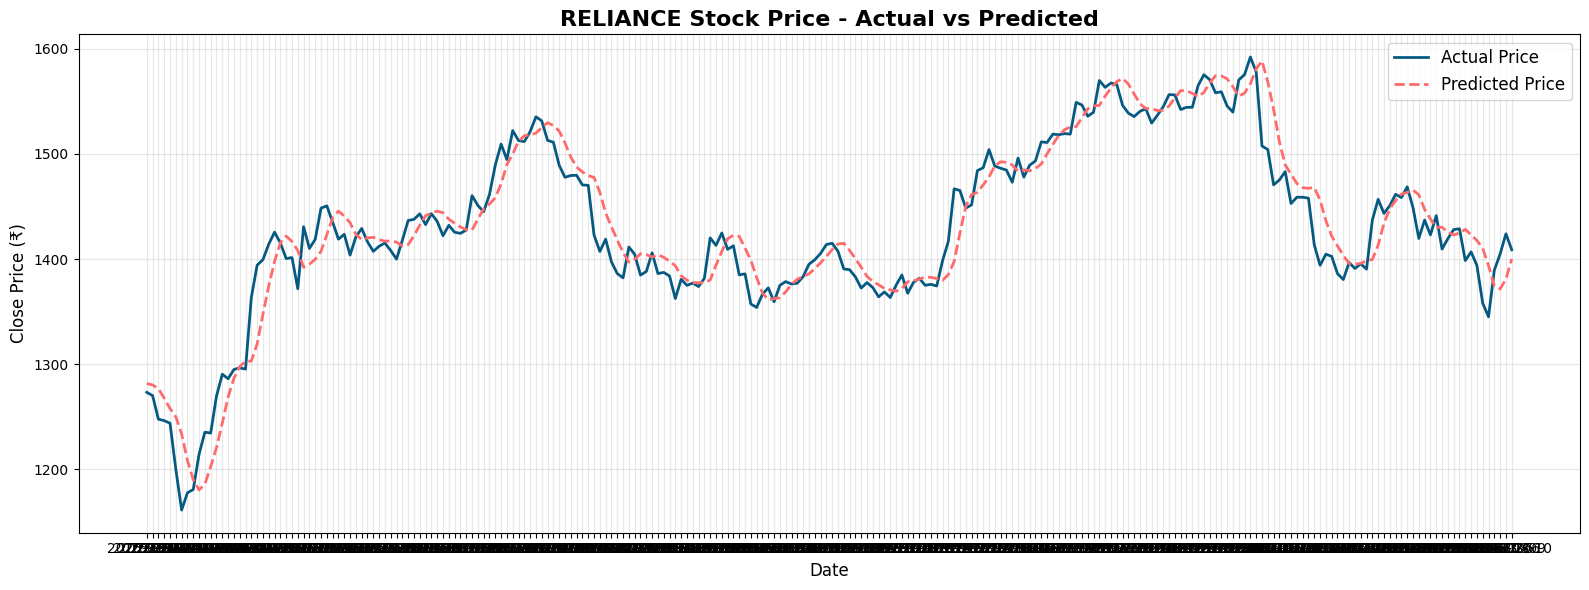

In [17]:
## Get test dates
test_dates = df.index[sequence_length + split:]

## Plot predictions
plt.figure(figsize=(16, 6))
plt.plot(test_dates, y_test, label='Actual Price', color='#065A82', linewidth=2)
plt.plot(test_dates, predictions, label='Predicted Price', color='#FF6B6B', linewidth=2, linestyle='--')
plt.title('RELIANCE Stock Price - Actual vs Predicted', fontsize=16, weight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price (₹)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 7: Error Analysis

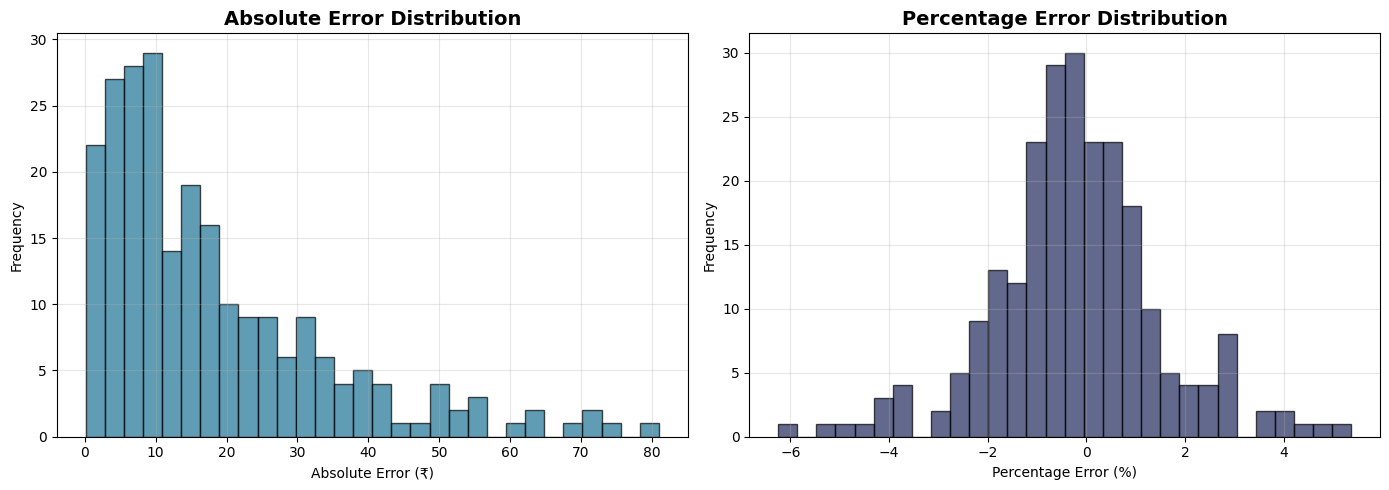

Mean Error: ₹-3.01
Std Error: ₹24.02
Max Overestimation: ₹-80.97
Max Underestimation: ₹74.83


In [18]:
## Calculate errors
errors = y_test - predictions.flatten()
percentage_errors = (errors / y_test) * 100

## Plot error distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute error distribution
axes[0].hist(np.abs(errors), bins=30, color='#1C7293', alpha=0.7, edgecolor='black')
axes[0].set_title('Absolute Error Distribution', fontsize=14, weight='bold')
axes[0].set_xlabel('Absolute Error (₹)')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)

# Percentage error distribution
axes[1].hist(percentage_errors, bins=30, color='#21295C', alpha=0.7, edgecolor='black')
axes[1].set_title('Percentage Error Distribution', fontsize=14, weight='bold')
axes[1].set_xlabel('Percentage Error (%)')
axes[1].set_ylabel('Frequency')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean Error: ₹{np.mean(errors):.2f}")
print(f"Std Error: ₹{np.std(errors):.2f}")
print(f"Max Overestimation: ₹{np.min(errors):.2f}")
print(f"Max Underestimation: ₹{np.max(errors):.2f}")

## Step 8: Scatter Plot - Actual vs Predicted

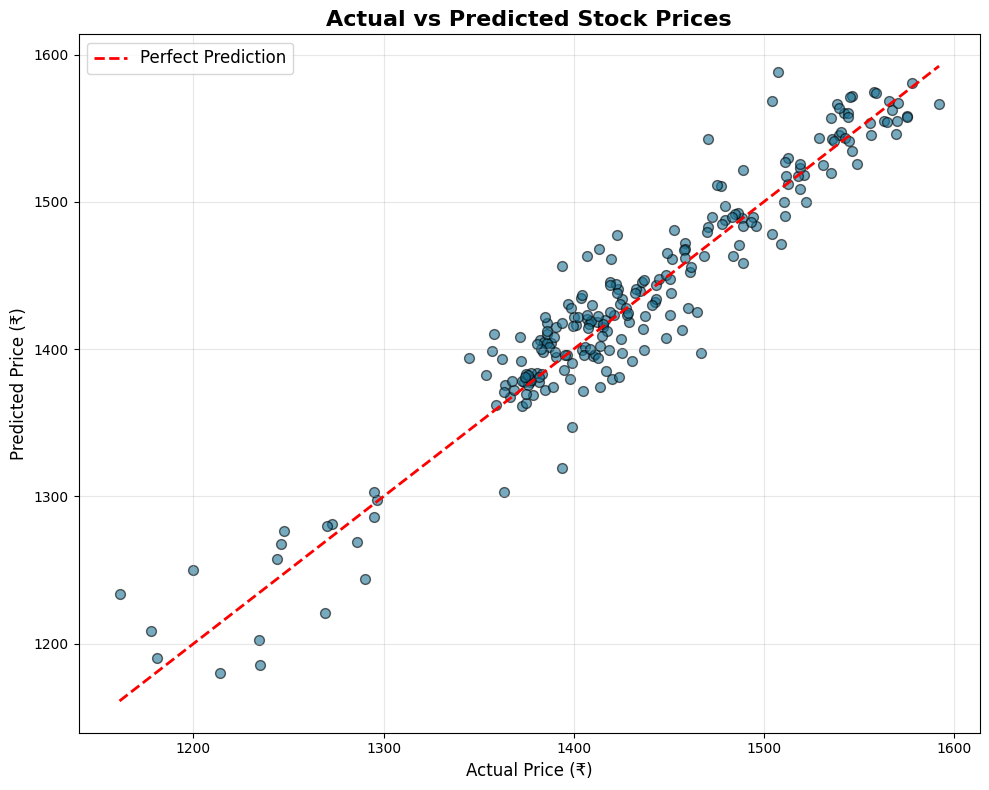

In [19]:
## Scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(y_test, predictions, alpha=0.6, color='#1C7293', edgecolor='black', s=50)

## Perfect prediction line
min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.title('Actual vs Predicted Stock Prices', fontsize=16, weight='bold')
plt.xlabel('Actual Price (₹)', fontsize=12)
plt.ylabel('Predicted Price (₹)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 9: Test on Different Stock (TCS)

In [22]:
## Load TCS data
df_tcs = pd.read_csv('data/TCS.csv', index_col=0, parse_dates=True)

df_tcs['Close'] = pd.to_numeric(df_tcs['Close'], errors='coerce')
df_tcs = df_tcs.dropna(subset=['Close'])

data_tcs = df_tcs[['Close']].values
scaled_data_tcs = scaler.transform(data_tcs)


## Create sequences
X_tcs = []
y_tcs = []

for i in range(60, len(scaled_data_tcs)):
    X_tcs.append(scaled_data_tcs[i-60:i, 0])
    y_tcs.append(data_tcs[i, 0])

X_tcs = np.array(X_tcs)
y_tcs = np.array(y_tcs)

## Use last 20% as test
split_tcs = int(0.8 * len(X_tcs))
X_test_tcs = X_tcs[split_tcs:].reshape(-1, 60, 1)
y_test_tcs = y_tcs[split_tcs:]

## Predict
predictions_tcs_scaled = model.predict(X_test_tcs, verbose=0)
predictions_tcs = scaler.inverse_transform(predictions_tcs_scaled)

## Calculate metrics
rmse_tcs = math.sqrt(mean_squared_error(y_test_tcs, predictions_tcs))
mae_tcs = mean_absolute_error(y_test_tcs, predictions_tcs)
mape_tcs = np.mean(np.abs((y_test_tcs - predictions_tcs.flatten()) / y_test_tcs)) * 100

print("TCS Stock Prediction Results:")
print(f"RMSE: ₹{rmse_tcs:.2f}")
print(f"MAE: ₹{mae_tcs:.2f}")
print(f"MAPE: {mape_tcs:.2f}%")

TCS Stock Prediction Results:
RMSE: ₹149.48
MAE: ₹136.84
MAPE: 4.31%


## Step 10: Future Prediction Function (Next 7 Days)

In [24]:
def predict_future(stock_name, days=7):
    """
    Predict future stock prices
    
    Args:
        stock_name: Stock ticker (e.g., 'RELIANCE')
        days: Number of days to predict
    """
    ## Load stock data
    df = pd.read_csv(f'data/{stock_name}.csv', index_col=0, parse_dates=True)

    df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
    df = df.dropna(subset=['Close'])
    
    data = df[['Close']].values
    
    ## Scale data
    scaled_data = scaler.transform(data)
    
    ## Use last 60 days
    last_60_days = scaled_data[-60:]
    
    ## Predict future
    predictions = []
    current_batch = last_60_days.copy()
    
    for i in range(days):
        # Reshape
        current_batch_reshaped = current_batch.reshape(1, 60, 1)
        
        # Predict
        pred_scaled = model.predict(current_batch_reshaped, verbose=0)
        pred_price = scaler.inverse_transform(pred_scaled)[0][0]
        predictions.append(pred_price)
        
        # Update batch
        current_batch = np.append(current_batch[1:], pred_scaled)
    
    return predictions

## Example: Predict next 7 days for RELIANCE
future_prices = predict_future('RELIANCE', days=7)

print("\nNext 7 Days Prediction for RELIANCE:")
print("="*40)
for i, price in enumerate(future_prices, 1):
    print(f"Day {i}: ₹{price:.2f}")
print("="*40)


Next 7 Days Prediction for RELIANCE:
Day 1: ₹1413.38
Day 2: ₹1421.27
Day 3: ₹1426.31
Day 4: ₹1429.60
Day 5: ₹1431.73
Day 6: ₹1433.07
Day 7: ₹1433.91


## Summary

In [25]:
print("\n" + "="*60)
print("TESTING AND EVALUATION COMPLETED!")
print("="*60)
print("\nKey Results:")
print(f"  • RMSE: ₹{rmse:.2f}")
print(f"  • MAE: ₹{mae:.2f}")
print(f"  • MAPE: {mape:.2f}%")
print(f"  • Directional Accuracy: {directional_accuracy:.2f}%")
print(f"  • R² Score: {r2:.4f}")
print("\nNext Step: Run 'streamlit run main.py' for web application")
print("="*60)


TESTING AND EVALUATION COMPLETED!

Key Results:
  • RMSE: ₹24.21
  • MAE: ₹18.00
  • MAPE: 1.28%
  • Directional Accuracy: 53.19%
  • R² Score: 0.9099

Next Step: Run 'streamlit run main.py' for web application
